

Импортируйте файл Event_click.xlsx.\
В нем содержатся результаты A/B теста, который проводился в онлайн-кинотеатре. В рамках эксперимента тестировалась новая рекомендательная система, цель которой - убедить пользователя просмотреть тот или иной тайтл.\
Описание данных:
- id_client - уникальный идентификатор клиента
- dtime_event - дата совершения события (временная часть опущена для облегчения данных)
- flag_group - флаг принадлежности к тестовой группе (1 - тест, 0 -контроль).
- event - залогированное клиентское событие (play - пригрывание плеера, click - клик мышкой, scroll - прокручивание страницы)

Необходимо подготовить данные к анализу результатов A/B теста.
Для этого:
1. Определите количество нуллов в рамках каждого столбца (и их пересечений) и исключите все записи, в которых отсутствует информация хотя бы в одном поле.
2. Выявите клиентов, которые в течение эксперимента попадали в разные группы (*Подсказка: рассчитайте количество уникальных значений поля flag_group на каждого клиента*)
3. Исключите этих клиентов из выборки.
4. Оцените общее количество исключений (относительно всей выборки)


In [94]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind
import datetime as dt
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [96]:
df = pd.read_excel('Event_click.xlsx', engine='openpyxl')
df.head()

,id_client,dtime_event,flag_group,event
0,1012904.0,2024-01-04,1.0,scroll
1,1009690.0,2024-01-25,0.0,click
2,1014159.0,2024-01-24,1.0,scroll
3,1010542.0,2024-01-23,0.0,play
4,1013213.0,2024-01-20,0.0,scroll


In [98]:
null_counts = df.isnull().sum()
df_clean = df.dropna()
dual_group = df_clean.groupby('id_client')['flag_group'].nunique()
dual_clients = dual_group[dual_group > 1].index
new_df = df_clean[~df_clean['id_client'].isin(dual_clients)]
print('Количество пропусков по столбцам:')
print(null_counts)
print('Пересечения пропусков:')
print("id_client + dtime_event:", len(df[df['id_client'].isnull() & df['dtime_event'].isnull()]))
print("id_client + flag_group:", len(df[df['id_client'].isnull() & df['flag_group'].isnull()]))
print("id_client + event:", len(df[df['id_client'].isnull() & df['event'].isnull()]))
print("Все поля пустые:", len(df[df.isnull().all(axis=1)]))
print('Исходных записей:',len(df))
print('Удалено из-за пропусков:', len(df) - len(df_clean))
print('Удалено клиентов в обеих группах:',len(df_clean) - len(new_df))
print('Удалено всего',len(df) - len(df_clean)+len(df_clean) - len(new_df))
print('Очищенная выборка:',len(new_df)) 

Количество пропусков по столбцам:
id_client       94
dtime_event      0
flag_group     392
event          513
dtype: int64
Пересечения пропусков:
id_client + dtime_event: 0
id_client + flag_group: 0
id_client + event: 0
Все поля пустые: 0
Исходных записей: 10554
Удалено из-за пропусков: 742
Удалено клиентов в обеих группах: 36
Удалено всего 778
Очищенная выборка: 9776



Задача новой рекомендательной системы заключается в том, чтобы повысить процент людей, которые при заходе на нашу страницу (то есть при совершении любого действия) перейдут в плеер (то есть совершат действие play).

Рассчитайте отдельно для *контрольной* и *тестовой* группы процент пользователей, которые совершили хотя бы одно действие play. Можете ли вы сделать вывод о значимом улучшении конверсии в просмотр?


In [101]:
df_analysis = new_df.assign(flag_play=new_df['event'].apply(lambda x: 1 if x == 'play' else 0))
user_play = df_analysis.groupby(['id_client', 'flag_group'])['flag_play'].max().reset_index()
user_play = user_play.rename(columns={'flag_play': 'max_flag'})
control = user_play.query("flag_group == 0")['max_flag']
test = user_play.query("flag_group == 1")['max_flag']
control_conv = control.mean()
test_conv = test.mean()
s, p = ttest_ind(test, control)
print('Конверсия в контрольной группе:',round(control_conv,2))
print('Конверсия в тестовой группе:', round(test_conv,2))
if p < 0.05: 
    print('Статистически значимое различие', s,p)
else:
    print('Статистически незначимое различие',s,p)

Конверсия в контрольной группе: 0.28
Конверсия в тестовой группе: 0.31
Статистически значимое различие 2.655959605685953 0.00792921558490156


Вывод: Новая рекомендательная система действительно увеличила конверсию в просмотр.

Рассчитайте DAU и WAU по имеющимся данным.\
Допустим, активностью пользователя является любая активность (совершение любого действия, хотя бы одного).Какие выводы можно сделать на основании имеющихся данных?


In [105]:
new_df = new_df.assign(
    date=lambda x: pd.to_datetime(x['dtime_event']),
    day=lambda x: x['date'].dt.date,
    week=lambda x: (x['date'].dt.isocalendar().year.astype(str) + '-W' + x['date'].dt.isocalendar().week.astype(str).str.zfill(2)))
new_df.head()

,id_client,dtime_event,flag_group,event,date,day,week
0,1012904.0,2024-01-04,1.0,scroll,2024-01-04,2024-01-04,2024-W01
1,1009690.0,2024-01-25,0.0,click,2024-01-25,2024-01-25,2024-W04
2,1014159.0,2024-01-24,1.0,scroll,2024-01-24,2024-01-24,2024-W04
3,1010542.0,2024-01-23,0.0,play,2024-01-23,2024-01-23,2024-W04
4,1013213.0,2024-01-20,0.0,scroll,2024-01-20,2024-01-20,2024-W03


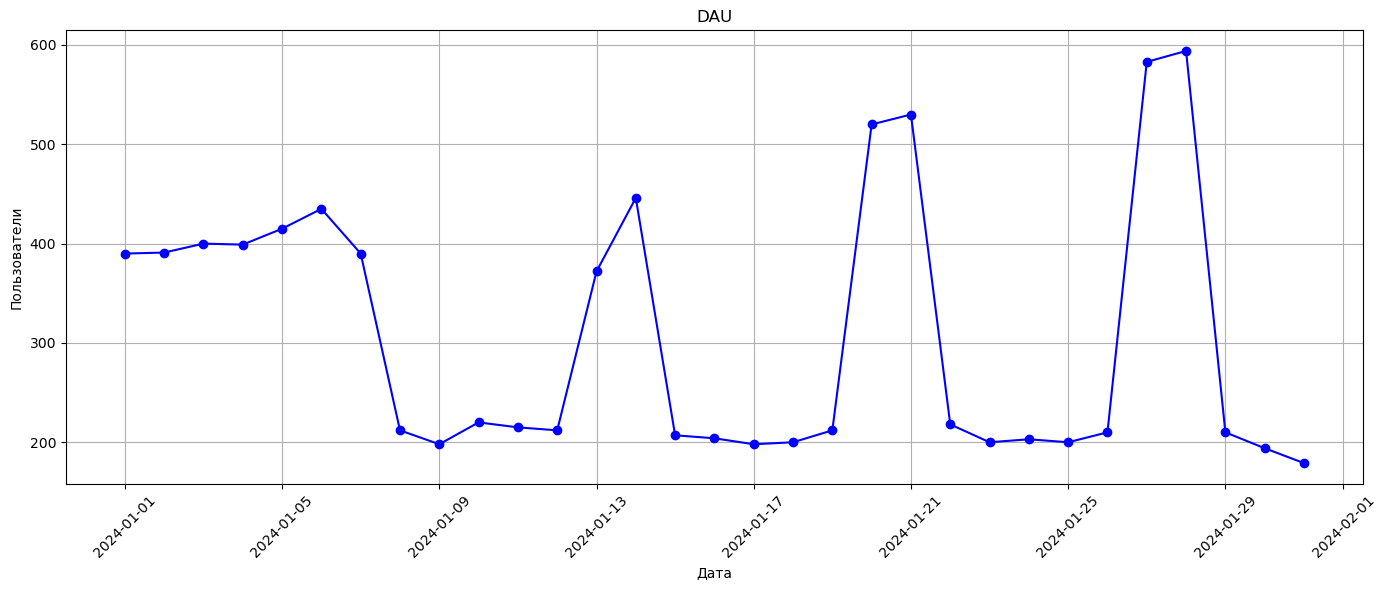

In [107]:
dau = new_df.groupby('day')['id_client'].nunique().sort_index()
plt.figure(figsize=(14, 6))
plt.plot(dau.index, dau.values, marker='o', linestyle='-', color='blue')
plt.title('DAU')
plt.xlabel('Дата')
plt.ylabel('Пользователи')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

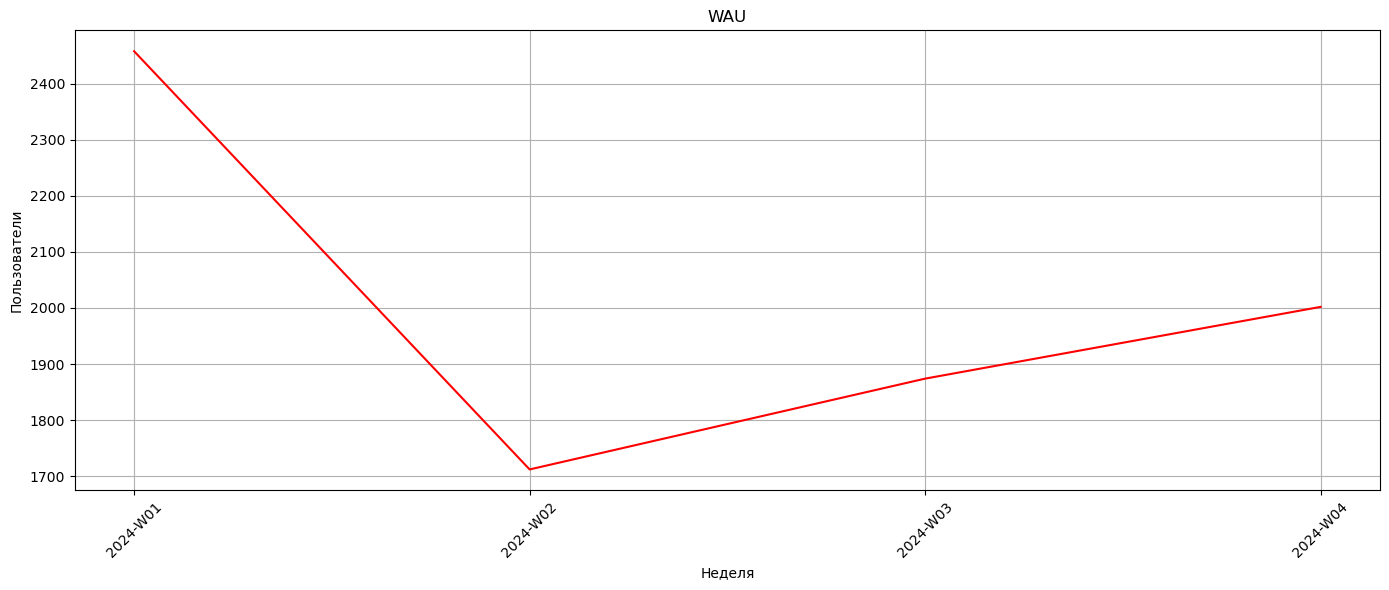

In [109]:
complete_weeks = (new_df.groupby('week')['day'].nunique() == 7)
wau = (new_df[new_df['week'].isin(complete_weeks[complete_weeks].index)]
       .groupby('week')['id_client']
       .nunique()
       .sort_index())
plt.figure(figsize=(14, 6))
plt.plot(wau.index, wau.values, color='red')
plt.title('WAU')
plt.xlabel('Неделя')
plt.ylabel('Пользователи')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

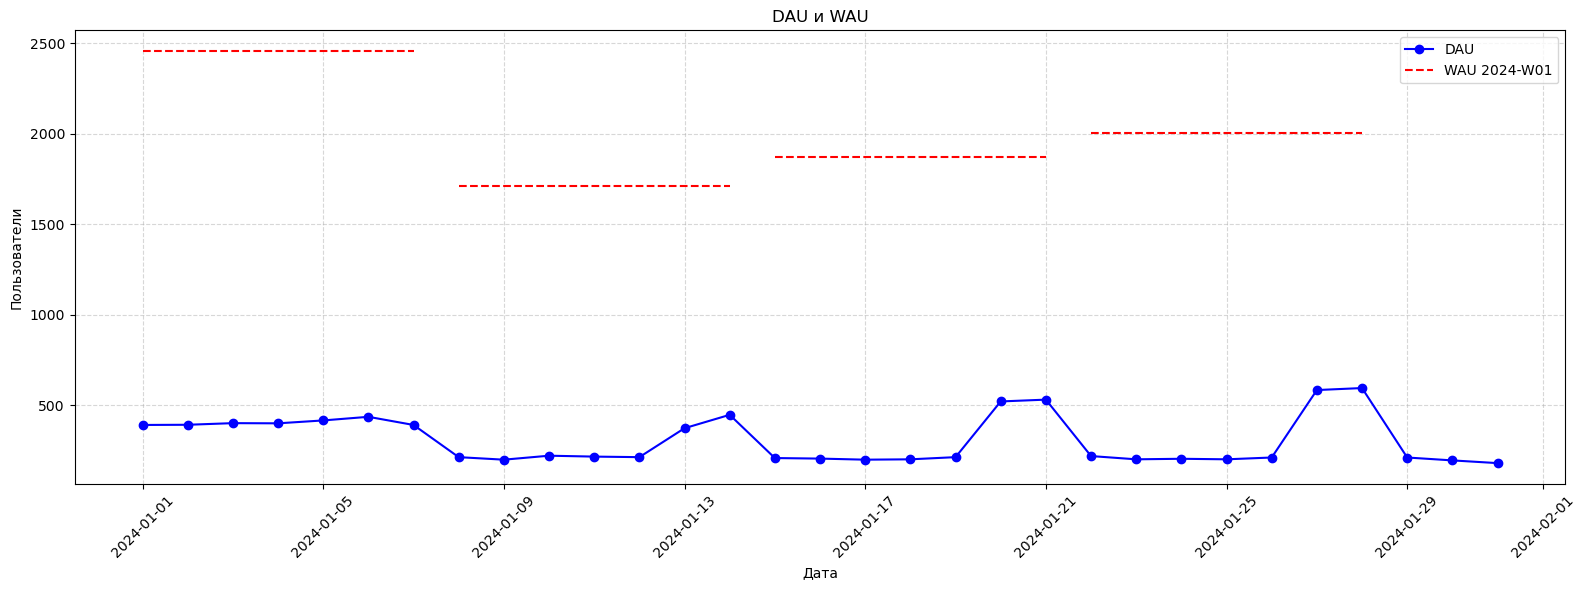

In [111]:
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(dau.index, dau.values, label='DAU', marker='o', linestyle='-', color='blue')
for week in wau.index:
    week_dates = new_df[new_df['week'] == week]['date']
    ax.hlines(y=wau[week], 
              xmin=week_dates.min(), 
              xmax=week_dates.max(),
              colors='red',
              linestyles='--',
              label=f'WAU {week}' if week == wau.index[0] else "")

ax.set_title('DAU и WAU')
ax.set_xlabel('Дата')
ax.set_ylabel('Пользователи')
plt.xticks(rotation=45)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [113]:
ratio = wau.mean()/dau.mean()
ratio

6.524693941613477

Выводы:
Ежедневная активность (DAU) пользователей показывает стабильный рост с небольшими колебаниями.
Пики активности обычно приходятся на выходные и праздничные дни.
Еженедельная активность (WAU) более стабильна. Соотношение WAU/DAU показывает, что большинство пользователей активны несколько раз в неделю. Виден устойчивый рост активности с течением времени, отдельные всплески возможно связаны с маркетинговыми активностями. Но также есть  дни с аномально низкой активностью, что может быть связано с техническими сбоями. 

Изменятся ли выводы, если поменять определение "активности"? \
В качестве "активности" возьмите действие play (то есть остальные действия не считаются за "клиентскую активность")

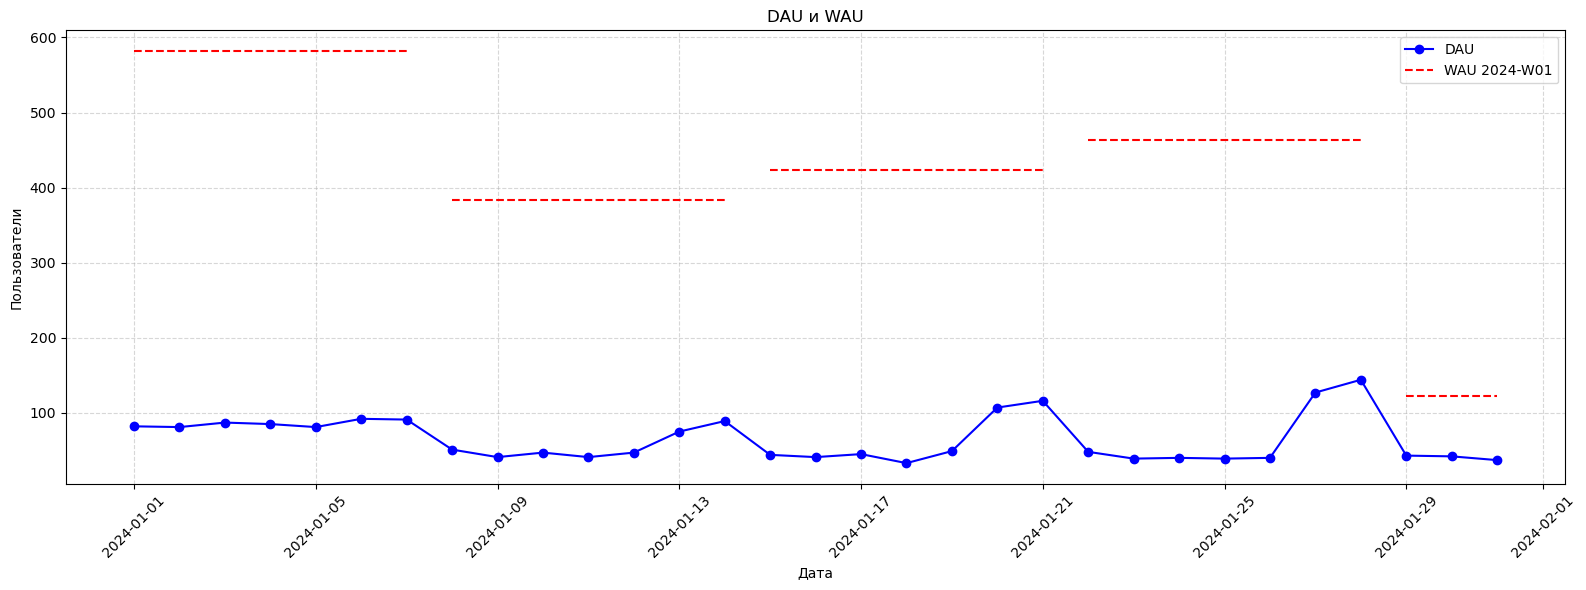

In [117]:
play_df = new_df[new_df['event'] == 'play']
dau_pl = play_df.groupby('day')['id_client'].nunique()
wau_pl = play_df.groupby('week')['id_client'].nunique().sort_index()

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(dau_pl.index, dau_pl.values, label='DAU', marker='o', linestyle='-', color='blue')
for week in wau_pl.index:
    week_dates = new_df[new_df['week'] == week]['date']
    ax.hlines(y=wau_pl[week], 
              xmin=week_dates.min(), 
              xmax=week_dates.max(),
              colors='red',
              linestyles='--',
              label=f'WAU {week}' if week == wau_pl.index[0] else "")
ax.set_title('DAU и WAU')
ax.set_xlabel('Дата')
ax.set_ylabel('Пользователи')
plt.xticks(rotation=45)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Вывод:  Если считать активными только тех клиентов, которые нажимают "play", то ежедневная активность (DAU) пользователей особо не меняется, пики активности редкие, роста активности нет.  Еженедельная активность также в несколько раз превышает ежедневную,  то есть клиенты активны несколько раз в неделю. Наиболее высокий WAU в праздничные дни (1-5 января)


In [122]:
ratio_pl = wau_pl.mean()/dau_pl.mean()
ratio_pl

6.0468379446640315